[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/Quantlets/Ch_06/MFM_ch6_corr_inference/MFM_ch6_corr_inference.ipynb)

# MFM_ch6_corr_inference

Inference on correlations and DCC: delta-method HAC standard errors of a correlation versus Fisher intervals (SPY-TLT), the Wied-Kramer-Dehling test for a change in correlation at an unknown date on GARCH residuals, two-step DCC standard errors by a parametric residual bootstrap of both steps, an out-of-sample DCC hedge of BET with the Euro Stoxx 50 with a Diebold-Mariano test, and a Forbes-Rigobon test with an estimated variance ratio (stationary bootstrap).

*Modelling Financial Markets (MFM), Chapter 6: Multivariate Volatility and Dependence. Author: Daniel Traian Pele.*

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/MFM/Chapter_6'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import networkx as nx
from scipy import stats, optimize, integrate
from scipy.signal import lfilter
from scipy.special import gammaln
try:
    from arch import arch_model
except ImportError:                      # Colab: pip install arch
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'arch'], check=True)
    from arch import arch_model
import warnings
warnings.filterwarnings('ignore')

## Style and helpers

In [2]:
# Stil standard MFM (identic cu SFM): transparent + ENG + legenda jos
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Culori brand
MainBlue = '#1A3A6E'
IDAred   = '#CD0000'
Forest   = '#2E7D32'
Amber    = '#B5853F'
Orange   = '#E67E22'
Purple   = '#8E44AD'
Crimson  = '#DC3545'
Gray     = '#7F7F7F'
LightGray = '#DADADA'
FAM_COL = {'gaussian': MainBlue, 't': IDAred, 'clayton': Forest, 'gumbel': Amber, 'frank': Purple}

SIDE = (5.6, 3.5)   # graficele asezate langa text pe slide (coloana de 0.55 din latime)

SEED = 42
NUM = {}
TABLE_DIR = '.'


def save_fig(name):
    """Salveaza figura ca PDF si PNG transparent, in folderul curent."""
    plt.savefig(f'{name}.pdf', bbox_inches='tight', transparent=True)
    plt.savefig(f'{name}.png', bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()
    print(f"   saved {name}")


def legend_outside_bottom(ax, ncol=2, y=-0.22):
    """Plaseaza legenda in afara graficului, jos-centru."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def shade_crises(ax, alpha=0.12):
    for a, b in (('2008-09-15', '2009-03-31'), ('2020-02-20', '2020-04-30'), ('2022-01-03', '2022-10-31')):
        ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color=Gray, alpha=alpha, lw=0)

## Data

In [3]:
import os
import numpy as np
import pandas as pd

REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'

# nume -> (simbol, coloana, eticheta, data de start)
ASSETS = {
    'spy':   ('SPY.US',        'adjusted_close', 'SPY (S&P 500 ETF)',          '2002-07-30'),
    'tlt':   ('TLT.US',        'adjusted_close', 'TLT (20+y Treasury ETF)',    '2002-07-30'),
    'ief':   ('IEF.US',        'adjusted_close', 'IEF (7-10y Treasury ETF)',   '2002-07-30'),
    'sp500': ('GSPC.INDX',     'close',          'S&P 500',                    '2000-01-01'),
    'stoxx': ('STOXX50E.INDX', 'close',          'Euro Stoxx 50',              '2000-01-01'),
    'bet':   ('BET',           'close',          'BET (Romania)',              '2000-01-01'),
    'bettr': ('BETTR.INDX',    'close',          'BET-TR (Romania)',           '2014-09-23'),
    'btc':   ('BTC-USD.CC',    'close',          'Bitcoin',                    '2014-09-17'),
    'vix':   ('VIX.INDX',      'close',          'VIX',                        '2000-01-01'),
    'jpm':   ('JPM.US',        'adjusted_close', 'JPMorgan Chase',             '2010-01-01'),
    'bac':   ('BAC.US',        'adjusted_close', 'Bank of America',            '2010-01-01'),
    'dbk':   ('DBK.XETRA',     'adjusted_close', 'Deutsche Bank',              '2010-01-01'),
    'bnp':   ('BNP.PA',        'adjusted_close', 'BNP Paribas',                '2010-01-01'),
    'tlv':   ('TLV.RO',        'adjusted_close', 'Banca Transilvania',         '2010-01-01'),
    'brd':   ('BRD.RO',        'adjusted_close', 'BRD-Groupe Societe Generale', '2010-01-01'),
}
# ETF-urile listate in SUA pentru studiul de caz COVOL (Engle si Campos-Martins, 2023, Sectiunea 9)
COVOL_ETFS = ['XLB', 'XLC', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLRE', 'XLU', 'XLV', 'XLY',
              'IWF', 'IWD', 'IWM', 'EFA', 'EEM', 'GLD', 'TLT', 'LQD', 'USO']
for _e in COVOL_ETFS:
    ASSETS['etf_' + _e.lower()] = (f'{_e}.US', 'adjusted_close', _e, '1999-12-31')
LABELS = {k: v[2] for k, v in ASSETS.items()}
SHORT = {'spy': 'SPY', 'tlt': 'TLT', 'ief': 'IEF', 'sp500': 'S&P 500', 'stoxx': 'Euro Stoxx 50', 'bet': 'BET',
         'bettr': 'BET-TR', 'btc': 'Bitcoin', 'vix': 'VIX', 'jpm': 'JPM', 'bac': 'BAC', 'dbk': 'DBK', 'bnp': 'BNP',
         'tlv': 'TLV', 'brd': 'BRD'}
BANKS = ['jpm', 'bac', 'dbk', 'bnp', 'tlv', 'brd']


def read_market(symbol):
    """Seria zilnica <SIMBOL> (data/market)."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def load_price(name, start=None, end=END):
    """Pretul zilnic curatat dupa conventiile capitolului."""
    symbol, col, _, start0 = ASSETS[name]
    d = read_market(symbol).loc[start or start0:end]
    d = d[d[col] > 0].dropna(subset=[col])
    s = d[col]
    if name != 'btc':
        keep = s.index.dayofweek < 5                                   # fara cotatii de weekend
        vol = d['volume'].fillna(0) if 'volume' in d else pd.Series(0.0, index=d.index)
        keep &= ~((s.diff() == 0) & (vol <= 0)).values                # sarbatori: pret neschimbat SI volum zero
        s = s[keep]                                                    # (zilele cu volum si pret neschimbat raman)
    return s.rename(name)


def joint_prices(names, start=None, end=END):
    """Preturile activelor in zilele comune (join interior pe preturi)."""
    return pd.concat([load_price(n, start, end) for n in names], axis=1, join='inner').dropna()


def joint_returns(names, start=None, end=END):
    """Randamente log zilnice calculate DUPA join-ul pe preturi (zile comune)."""
    return np.log(joint_prices(names, start, end)).diff().dropna()


def weekly_returns(names, start=None, end=END):
    """Randamente log saptamanale: ultimul pret comun din fiecare saptamana (vineri), apoi diferente."""
    p = joint_prices(names, start, end)
    return np.log(p.resample('W-FRI').last()).diff().dropna()

## Dependence tools: EWMA, GARCH, DCC, Forbes-Rigobon, copulas

In [4]:
import numpy as np
import pandas as pd
from scipy import stats, optimize, integrate
from scipy.signal import lfilter
from scipy.special import gammaln
from arch import arch_model
try:
    from numba import njit
except ImportError:                      # without numba the same functions run as plain Python (slower)
    def njit(*args, **kwargs):
        return args[0] if (len(args) == 1 and callable(args[0])) else (lambda f: f)


# =============================================================================
# EWMA si fereastra mobila
# =============================================================================
def ewma_cov(R, lam=0.94, init=100):
    """Sigma_t = lam*Sigma_{t-1} + (1-lam) r_{t-1} r_{t-1}'  (prognoza pentru ziua t, fara r_t).
    Primele init observatii servesc doar la initializare: Sigma_init = covarianta lor; inainte de init, NaN."""
    X = np.asarray(R, dtype=float)
    T, N = X.shape
    S = np.full((T, N, N), np.nan)
    S[init] = np.cov(X[:init].T)
    for t in range(init + 1, T):
        S[t] = lam * S[t - 1] + (1 - lam) * np.outer(X[t - 1], X[t - 1])
    return S


def ewma_corr(R, lam=0.94, i=0, j=1):
    S = ewma_cov(R, lam)
    return pd.Series(S[:, i, j] / np.sqrt(S[:, i, i] * S[:, j, j]), index=R.index)


def rolling_corr(R, window, a=None, b=None):
    a, b = a or R.columns[0], b or R.columns[1]
    return R[a].rolling(window).corr(R[b])


def fisher_ci(rho, n, level=0.95):
    """Interval de incredere pentru corelatie prin transformarea Fisher z (date i.i.d.)."""
    z, se = np.arctanh(rho), 1 / np.sqrt(n - 3)
    q = stats.norm.ppf(0.5 + level / 2)
    return np.tanh(z - q * se), np.tanh(z + q * se)


# =============================================================================
# GARCH(1,1) univariat -- primul pas al DCC
# =============================================================================
def garch_filter(r, dist='normal'):
    """GARCH(1,1) cu medie constanta pe randamente in procente (QML).
    Intoarce parametrii, volatilitatea conditionala (%) si reziduurile standardizate."""
    res = arch_model(100 * r, mean='Constant', vol='GARCH', p=1, q=1, dist=dist).fit(disp='off')
    z = (res.resid / res.conditional_volatility).rename(r.name)
    return res.params, res.conditional_volatility.rename(r.name), z, res.loglikelihood


def garch_all(R, dist='normal'):
    out = {c: garch_filter(R[c], dist) for c in R.columns}
    Z = pd.concat([out[c][2] for c in R.columns], axis=1)
    V = pd.concat([out[c][1] for c in R.columns], axis=1)
    P = pd.DataFrame({c: out[c][0] for c in R.columns})
    ll = sum(out[c][3] for c in R.columns)
    return P, V, Z, ll


# =============================================================================
# DCC (Engle, 2002): Q_t = (1-a-b) Qbar + a z_{t-1} z_{t-1}' + b Q_{t-1}
# =============================================================================
def dcc_path(Z, a, b, Qbar=None):
    """Matricele de corelatie R_t (T x N x N). Fiecare element al lui Q_t urmeaza o recursie
    liniara, calculata vectorial cu lfilter."""
    X = np.asarray(Z, dtype=float)
    T, N = X.shape
    Qbar = np.cov(X.T, bias=True) if Qbar is None else Qbar
    P = np.einsum('ti,tj->tij', X, X)                  # z_t z_t'
    drive = np.empty_like(P)
    drive[0] = Qbar
    drive[1:] = (1 - a - b) * Qbar + a * P[:-1]         # intrare la momentul t: foloseste z_{t-1}
    Q = lfilter([1.0], [1.0, -b], drive.reshape(T, -1), axis=0).reshape(T, N, N)
    Q[0] = Qbar
    d = np.sqrt(np.einsum('tii->ti', Q))
    return Q / (d[:, :, None] * d[:, None, :])


@njit(cache=True)
def dcc2_corr_loglik(x, y, a, b, q11b, q22b, q12b):
    """Cazul bivariat al lui dcc_corr_loglik, scris ca o singura bucla (aceeasi recursie ca dcc_path)."""
    q11, q22, q12 = q11b, q22b, q12b
    c = 1.0 - a - b
    ll = 0.0
    for t in range(len(x)):
        r = q12 / np.sqrt(q11 * q22)
        d = 1.0 - r * r
        ll += -0.5 * (np.log(d) + (x[t] * x[t] + y[t] * y[t] - 2.0 * r * x[t] * y[t]) / d - x[t] * x[t] - y[t] * y[t])
        q11 = c * q11b + a * x[t] * x[t] + b * q11
        q22 = c * q22b + a * y[t] * y[t] + b * q22
        q12 = c * q12b + a * x[t] * y[t] + b * q12
    return ll


def dcc_corr_loglik(Z, a, b, Qbar=None):
    """Partea de corelatie a log-verosimilitatii: -1/2 sum(log|R_t| + z'R_t^{-1}z - z'z)."""
    X = np.asarray(Z, dtype=float)
    if X.shape[1] == 2:
        Q = np.cov(X.T, bias=True) if Qbar is None else Qbar
        return dcc2_corr_loglik(np.ascontiguousarray(X[:, 0]), np.ascontiguousarray(X[:, 1]), float(a), float(b),
                                Q[0, 0], Q[1, 1], Q[0, 1])
    R = dcc_path(X, a, b, Qbar)
    sign, logdet = np.linalg.slogdet(R)
    quad = np.einsum('ti,tij,tj->t', X, np.linalg.inv(R), X)
    return -0.5 * np.sum(logdet + quad - np.sum(X ** 2, axis=1))


def ccc_loglik(Z):
    """CCC (Bollerslev, 1990): corelatie constanta = DCC cu a = b = 0."""
    return dcc_corr_loglik(Z, 0.0, 0.0)


def _num_hessian(f, x, h=1e-4):
    k = len(x)
    H = np.zeros((k, k))
    for i in range(k):
        for j in range(k):
            e_i, e_j = np.eye(k)[i] * h, np.eye(k)[j] * h
            H[i, j] = (f(x + e_i + e_j) - f(x + e_i - e_j) - f(x - e_i + e_j) + f(x - e_i - e_j)) / (4 * h * h)
    return H


def dcc_fit(Z, start=(0.03, 0.95)):
    """Pasul 2 al DCC: (a, b) prin verosimilitate maxima, cu Qbar fixat la corelatia de selectie
    (correlation targeting). Erorile standard provin din hessiana pasului 2 (ignora eroarea pasului 1)."""
    X = np.asarray(Z, dtype=float)
    Qbar = np.cov(X.T, bias=True)

    def nll(p):
        a, b = p
        if a < 0 or b < 0 or a + b >= 0.9999:
            return 1e10
        return -dcc_corr_loglik(X, a, b, Qbar)

    best = None
    for s in (start, (0.01, 0.98), (0.05, 0.90), (0.10, 0.80)):
        r = optimize.minimize(nll, s, method='Nelder-Mead', options=dict(xatol=1e-7, fatol=1e-7, maxiter=4000))
        if best is None or r.fun < best.fun:
            best = r
    a, b = best.x
    try:
        H = _num_hessian(lambda p: -nll(p), best.x)
        se = np.sqrt(np.diag(np.linalg.inv(-H)))
    except Exception:
        se = np.array([np.nan, np.nan])
    return dict(a=a, b=b, se_a=se[0], se_b=se[1], loglik=-best.fun, Qbar=Qbar,
                R=dcc_path(X, a, b, Qbar), ccc_loglik=ccc_loglik(X))


# =============================================================================
# Forbes-Rigobon (2002)
# =============================================================================
def fr_adjust(rho_c, delta):
    """Corelatia din criza corectata pentru cresterea varianţei pietei-sursa:
    rho* = rho_c / sqrt(1 + delta (1 - rho_c^2)), delta = Var_criza/Var_calm - 1."""
    return rho_c / np.sqrt(1 + delta * (1 - rho_c ** 2))


def fr_inflation(rho, delta):
    """Corelatia masurata in criza cand corelatia adevarata nu se schimba: rho sqrt((1+delta)/(1+delta rho^2))."""
    return rho * np.sqrt((1 + delta) / (1 + delta * rho ** 2))


def fisher_z_test(rho1, n1, rho0, n0):
    """H0: rho1 <= rho0 (test unilateral, esantioane independente)."""
    z = (np.arctanh(rho1) - np.arctanh(rho0)) / np.sqrt(1 / (n1 - 3) + 1 / (n0 - 3))
    return z, 1 - stats.norm.cdf(z)


def crisis_table(ret2, source, targets, calm, crisis):
    """Corelatia calm vs criza, corectia Forbes-Rigobon si testul Fisher z pentru mai multe piete."""
    rows = []
    c0, c1 = ret2.loc[calm[0]:calm[1]], ret2.loc[crisis[0]:crisis[1]]
    delta = c1[source].var() / c0[source].var() - 1
    for tg in targets:
        r0, r1 = c0[source].corr(c0[tg]), c1[source].corr(c1[tg])
        adj = fr_adjust(r1, delta)
        n0, n1 = len(c0) // 2, len(c1) // 2          # randamente pe 2 zile suprapuse: n efectiv ~ n/2
        rows.append(dict(target=tg, rho_calm=r0, rho_crisis=r1, delta=delta, rho_adj=adj,
                         z_raw=fisher_z_test(r1, n1, r0, n0)[0], p_raw=fisher_z_test(r1, n1, r0, n0)[1],
                         z_adj=fisher_z_test(adj, n1, r0, n0)[0], p_adj=fisher_z_test(adj, n1, r0, n0)[1],
                         n_calm=len(c0), n_crisis=len(c1)))
    return pd.DataFrame(rows).set_index('target')


def exceedance_corr(x, y, qs):
    """Corelatia de depasire (Longin-Solnik, 2001): corr(x, y | x<q_x, y<q_y) pentru cozi joase si
    corr(x, y | x>q_x, y>q_y) pentru cozi inalte, la aceleasi cuantile marginale."""
    out = []
    for q in qs:
        lo = (x <= np.quantile(x, q)) & (y <= np.quantile(y, q))
        hi = (x >= np.quantile(x, 1 - q)) & (y >= np.quantile(y, 1 - q))
        out.append((q, np.corrcoef(x[lo], y[lo])[0, 1] if lo.sum() > 5 else np.nan, lo.sum(),
                    np.corrcoef(x[hi], y[hi])[0, 1] if hi.sum() > 5 else np.nan, hi.sum()))
    return pd.DataFrame(out, columns=['q', 'rho_low', 'n_low', 'rho_high', 'n_high']).set_index('q')


# =============================================================================
# Copule bivariate
# =============================================================================
FAMILIES = ['gaussian', 't', 'clayton', 'gumbel', 'frank']
FAM_LABEL = {'gaussian': 'Gaussian', 't': 'Student t', 'clayton': 'Clayton', 'gumbel': 'Gumbel', 'frank': 'Frank'}
EPS = 1e-10


def pseudo_obs(X):
    """Pseudo-observatii: rang / (n + 1), coloana cu coloana."""
    X = np.asarray(X, dtype=float)
    return np.column_stack([stats.rankdata(X[:, k]) / (len(X) + 1) for k in range(X.shape[1])])


def kendall_tau(u, v):
    return stats.kendalltau(u, v)[0]


def spearman_rho(u, v):
    return stats.spearmanr(u, v)[0]


def _debye1(x):
    if abs(x) < 1e-8:
        return 1.0
    val = integrate.quad(lambda t: t / np.expm1(t), 0, abs(x))[0] / abs(x)
    return val if x > 0 else val + abs(x) / 2


def tau_of(fam, theta):
    """Tau Kendall implicat de parametrul copulei."""
    if fam in ('gaussian', 't'):
        return 2 / np.pi * np.arcsin(theta[0] if np.ndim(theta) else theta)
    th = float(np.atleast_1d(theta)[0])
    if fam == 'clayton':
        return th / (th + 2)
    if fam == 'gumbel':
        return 1 - 1 / th
    if fam == 'frank':
        return 1 - 4 / th * (1 - _debye1(th))


def theta_from_tau(fam, tau):
    """Inversarea relatiei tau <-> parametru (metoda momentelor pe tau Kendall)."""
    if fam in ('gaussian', 't'):
        return np.sin(np.pi * tau / 2)
    if fam == 'clayton':
        return 2 * tau / (1 - tau)
    if fam == 'gumbel':
        return 1 / (1 - tau)
    if fam == 'frank':
        return optimize.brentq(lambda th: tau_of('frank', th) - tau, 1e-6 if tau > 0 else -60, 60 if tau > 0 else -1e-6)


def tail_dep(fam, par):
    """(lambda_L, lambda_U) pentru parametrii dati."""
    if fam == 'gaussian':
        return 0.0, 0.0
    if fam == 't':
        rho, nu = par
        lam = 2 * stats.t.cdf(-np.sqrt((nu + 1) * (1 - rho) / (1 + rho)), nu + 1)
        return lam, lam
    th = par[0]
    if fam == 'clayton':
        return 2 ** (-1 / th), 0.0
    if fam == 'gumbel':
        return 0.0, 2 - 2 ** (1 / th)
    return 0.0, 0.0


def log_density(fam, par, u, v):
    u = np.clip(u, EPS, 1 - EPS)
    v = np.clip(v, EPS, 1 - EPS)
    if fam == 'gaussian':
        rho = par[0]
        x, y = stats.norm.ppf(u), stats.norm.ppf(v)
        return -0.5 * np.log(1 - rho ** 2) - (rho ** 2 * (x ** 2 + y ** 2) - 2 * rho * x * y) / (2 * (1 - rho ** 2))
    if fam == 't':
        rho, nu = par
        x, y = stats.t.ppf(u, nu), stats.t.ppf(v, nu)
        return (gammaln((nu + 2) / 2) + gammaln(nu / 2) - 2 * gammaln((nu + 1) / 2) - 0.5 * np.log(1 - rho ** 2)
                - (nu + 2) / 2 * np.log1p((x ** 2 + y ** 2 - 2 * rho * x * y) / (nu * (1 - rho ** 2)))
                + (nu + 1) / 2 * (np.log1p(x ** 2 / nu) + np.log1p(y ** 2 / nu)))
    th = par[0]
    if fam == 'clayton':
        return (np.log1p(th) - (1 + th) * (np.log(u) + np.log(v))
                - (2 + 1 / th) * np.log(u ** -th + v ** -th - 1))
    if fam == 'gumbel':
        lu, lv = -np.log(u), -np.log(v)
        A = lu ** th + lv ** th
        Ath = A ** (1 / th)
        return (-Ath - np.log(u) - np.log(v) + (th - 1) * (np.log(lu) + np.log(lv))
                + (2 / th - 2) * np.log(A) + np.log1p((th - 1) / Ath))
    if fam == 'frank':
        e = -np.expm1(-th)
        den = e - (-np.expm1(-th * u)) * (-np.expm1(-th * v))
        return np.log(th * e) - th * (u + v) - 2 * np.log(np.abs(den))


def h_func(fam, par, u, v):
    """h(v|u) = dC(u,v)/du: functia de repartitie conditionata (transformata Rosenblatt)."""
    u = np.clip(u, EPS, 1 - EPS)
    v = np.clip(v, EPS, 1 - EPS)
    if fam == 'gaussian':
        rho = par[0]
        x, y = stats.norm.ppf(u), stats.norm.ppf(v)
        return stats.norm.cdf((y - rho * x) / np.sqrt(1 - rho ** 2))
    if fam == 't':
        rho, nu = par
        x, y = stats.t.ppf(u, nu), stats.t.ppf(v, nu)
        return stats.t.cdf((y - rho * x) / np.sqrt((nu + x ** 2) * (1 - rho ** 2) / (nu + 1)), nu + 1)
    th = par[0]
    if fam == 'clayton':
        return u ** (-th - 1) * (u ** -th + v ** -th - 1) ** (-1 / th - 1)
    if fam == 'gumbel':
        lu, lv = -np.log(u), -np.log(v)
        A = lu ** th + lv ** th
        return np.exp(-A ** (1 / th)) / u * lu ** (th - 1) * A ** (1 / th - 1)
    if fam == 'frank':
        a, b = np.expm1(-th * u), np.expm1(-th * v)
        return (a + 1) * b / (np.expm1(-th) + a * b)


def simulate(fam, par, n, rng):
    """Simulare de n perechi (u, v) din copula."""
    if fam == 'gaussian':
        rho = par[0]
        z = rng.multivariate_normal([0, 0], [[1, rho], [rho, 1]], n)
        return stats.norm.cdf(z)
    if fam == 't':
        rho, nu = par
        z = rng.multivariate_normal([0, 0], [[1, rho], [rho, 1]], n)
        w = np.sqrt(nu / rng.chisquare(nu, n))
        return stats.t.cdf(z * w[:, None], nu)
    th = par[0]
    if fam == 'clayton':          # Marshall-Olkin cu factor Gamma(1/theta)
        V = rng.gamma(1 / th, 1, n)
        E = rng.exponential(1, (n, 2))
        return (1 + E / V[:, None]) ** (-1 / th)
    if fam == 'gumbel':           # Marshall-Olkin cu factor stabil pozitiv, alpha = 1/theta (Kanter)
        al = 1 / th
        U = rng.uniform(0, np.pi, n)
        W = rng.exponential(1, n)
        S = np.sin(al * U) / np.sin(U) ** (1 / al) * (np.sin((1 - al) * U) / W) ** ((1 - al) / al)
        E = rng.exponential(1, (n, 2))
        return np.exp(-(E / S[:, None]) ** al)
    if fam == 'frank':            # inversarea functiei h
        u, w = rng.uniform(size=n), rng.uniform(size=n)
        v = -np.log1p(w * np.expm1(-th) / (w + (1 - w) * np.exp(-th * u))) / th
        return np.column_stack([u, v])


def fit_copula(fam, u, v):
    """Estimare ML pe pseudo-observatii (pseudo-verosimilitate canonica, CML)."""
    tau = kendall_tau(u, v)
    if fam == 'gaussian':
        f = lambda p: -np.sum(log_density('gaussian', [np.tanh(p[0])], u, v))
        r = optimize.minimize(f, [np.arctanh(np.sin(np.pi * tau / 2))], method='BFGS')
        par = [np.tanh(r.x[0])]
    elif fam == 't':
        f = lambda p: -np.sum(log_density('t', [np.tanh(p[0]), 2.01 + np.exp(p[1])], u, v))
        best = None
        for nu0 in (3, 6, 15):
            r = optimize.minimize(f, [np.arctanh(np.sin(np.pi * tau / 2)), np.log(nu0 - 2.01)], method='Nelder-Mead',
                                  options=dict(xatol=1e-6, fatol=1e-6))
            if best is None or r.fun < best.fun:
                best = r
        r = best
        par = [np.tanh(r.x[0]), 2.01 + np.exp(r.x[1])]
    else:
        lo, hi = {'clayton': (1e-4, 30), 'gumbel': (1.0001, 30), 'frank': (1e-4, 60)}[fam]
        f = lambda p: -np.sum(log_density(fam, [p], u, v))
        th0 = min(max(theta_from_tau(fam, max(tau, 0.02)), lo * 1.01), hi * 0.99)
        r = optimize.minimize_scalar(f, bounds=(lo, hi), method='bounded', options=dict(xatol=1e-7))
        if f(th0) < r.fun:
            r = optimize.minimize_scalar(f, bracket=(lo * 1.01, th0, hi * 0.99), bounds=(lo, hi), method='bounded')
        par = [r.x]
    ll = np.sum(log_density(fam, par, u, v))
    k = 2 if fam == 't' else 1
    lamL, lamU = tail_dep(fam, par)
    return dict(family=fam, par=list(map(float, par)), loglik=float(ll), aic=float(2 * k - 2 * ll),
                bic=float(k * np.log(len(u)) - 2 * ll), tau_model=float(tau_of(fam, par if fam in ('gaussian', 't') else par[0])),
                lamL=float(lamL), lamU=float(lamU))


def cvm_rosenblatt(fam, par, u, v, chunk=1500):
    """S_n^(B) (Genest, Remillard & Beaudoin, 2009): distanta Cramer-von Mises dintre repartitia
    empirica a perechilor Rosenblatt (u, h(v|u)) si copula de independenta."""
    E = np.column_stack([u, h_func(fam, par, u, v)])
    n = len(E)
    t1 = n / 9
    t2 = np.sum((1 - E[:, 0] ** 2) * (1 - E[:, 1] ** 2)) / 2
    t3 = 0.0
    for i in range(0, n, chunk):
        Ei = E[i:i + chunk]
        t3 += np.sum((1 - np.maximum(Ei[:, None, 0], E[None, :, 0])) * (1 - np.maximum(Ei[:, None, 1], E[None, :, 1])))
    return t1 - t2 + t3 / n


def gof_test(fam, u, v, B=200, seed=42, fit=None):
    """Test de adecvare cu bootstrap parametric: simulare din copula estimata, pseudo-observatii,
    re-estimare, statistica S_n^(B); p-valoarea = proportia statisticilor bootstrap >= cea observata."""
    fit = fit or fit_copula(fam, u, v)
    s0 = cvm_rosenblatt(fam, fit['par'], u, v)
    rng = np.random.default_rng(seed)
    sb = []
    for _ in range(B):
        X = simulate(fam, fit['par'], len(u), rng)
        U = pseudo_obs(X)
        fb = fit_copula(fam, U[:, 0], U[:, 1])
        sb.append(cvm_rosenblatt(fam, fb['par'], U[:, 0], U[:, 1]))
    sb = np.array(sb)
    return dict(stat=float(s0), p=float((1 + np.sum(sb >= s0)) / (B + 1)), B=B)


def empirical_tail_dep(u, v, q):
    """lambda_L(q) = P(U<=q, V<=q)/q si lambda_U(q) = P(U>1-q, V>1-q)/q."""
    return np.mean((u <= q) & (v <= q)) / q, np.mean((u > 1 - q) & (v > 1 - q)) / q

## Helper functions

In [5]:
CALM08, CRISIS08 = ('2007-09-14', '2008-09-12'), ('2008-09-15', '2009-03-31')
CALM20, CRISIS20 = ('2019-02-19', '2020-02-19'), ('2020-02-20', '2020-04-30')
N = {}

def two_day_returns(names, start='2006-01-01', end='2021-12-31'):
    """Randamente pe 2 zile (medie mobila, ca in Forbes-Rigobon): log p_t - log p_{t-2}, din preturi comune."""
    lp = np.log(joint_prices(names, start=start, end=end))
    return (lp - lp.shift(2)).dropna()


def stationary_bootstrap_idx(n, mean_block, rng):
    """Indicii unui bootstrap stationar (Politis-Romano): blocuri de lungime geometrica."""
    idx = np.empty(n, dtype=int)
    idx[0] = rng.integers(n)
    for t in range(1, n):
        idx[t] = rng.integers(n) if rng.uniform() < 1 / mean_block else (idx[t - 1] + 1) % n
    return idx


def simulate_dcc2(a, b, Qbar, eta):
    """Simuleaza reziduuri standardizate bivariate dintr-un DCC(1,1) cu inovatii decorelate eta (T x 2)."""
    T = len(eta)
    eps = np.empty_like(eta)
    q11, q22, q12 = Qbar[0, 0], Qbar[1, 1], Qbar[0, 1]
    c = 1 - a - b
    for t in range(T):
        r = q12 / np.sqrt(q11 * q22)
        eps[t, 0] = eta[t, 0]
        eps[t, 1] = r * eta[t, 0] + np.sqrt(1 - r * r) * eta[t, 1]
        q11 = c * Qbar[0, 0] + a * eps[t, 0] ** 2 + b * q11
        q22 = c * Qbar[1, 1] + a * eps[t, 1] ** 2 + b * q22
        q12 = c * Qbar[0, 1] + a * eps[t, 0] * eps[t, 1] + b * q12
    return eps

## Analysis

In [6]:
def bartlett_lrv(M, L):
    """Varianta pe termen lung (Newey-West, nucleu Bartlett cu L decalaje) a coloanelor lui M (centrate)."""
    M = np.asarray(M, dtype=float)
    M = M - M.mean(0)
    T = len(M)
    S = M.T @ M / T
    for l in range(1, L + 1):
        G = M[l:].T @ M[:-l] / T
        S += (1 - l / (L + 1)) * (G + G.T)
    return S


def corr_grad(m):
    """Gradientul lui rho = (m5 - m1 m2) / sqrt((m3 - m1^2)(m4 - m2^2)), m = (Ex, Ey, Ex^2, Ey^2, Exy)."""
    m1, m2, m3, m4, m5 = m
    vx, vy, c = m3 - m1 ** 2, m4 - m2 ** 2, m5 - m1 * m2
    r = c / np.sqrt(vx * vy)
    return r, np.array([-m2 / np.sqrt(vx * vy) + r * m1 / vx, -m1 / np.sqrt(vx * vy) + r * m2 / vy,
                        -r / (2 * vx), -r / (2 * vy), 1 / np.sqrt(vx * vy)])


def corr_delta_se(x, y, L=None):
    """Corelatia si trei erori standard: Fisher (i.i.d. Normal), metoda delta fara decalaje (momente de ordin 4)
    si metoda delta HAC (Bartlett, L = floor(4 (T/100)^(2/9)) implicit)."""
    x, y = np.asarray(x, float), np.asarray(y, float)
    T = len(x)
    L = int(np.floor(4 * (T / 100) ** (2 / 9))) if L is None else L
    M = np.column_stack([x, y, x * x, y * y, x * y])
    r, g = corr_grad(M.mean(0))
    se_iid = np.sqrt(g @ bartlett_lrv(M, 0) @ g / T)
    se_hac = np.sqrt(g @ bartlett_lrv(M, L) @ g / T)
    return dict(rho=r, se_fisher=(1 - r ** 2) / np.sqrt(T - 3), se_iid=se_iid, se_hac=se_hac, T=T, L=L)


def hac_ci(r, se, level=0.95):
    """Interval pe scara Fisher z cu eroarea standard data (metoda delta: se_z = se / (1 - r^2))."""
    q = stats.norm.ppf(0.5 + level / 2)
    z, sz = np.arctanh(r), se / (1 - r ** 2)
    return np.tanh(z - q * sz), np.tanh(z + q * sz)


def corr_hac_path(R, window=252, step=5):
    out = []
    X = R.values
    for e in range(window, len(R) + 1, step):
        s = corr_delta_se(X[e - window:e, 0], X[e - window:e, 1])
        lo_f, hi_f = fisher_ci(s['rho'], window)
        lo_h, hi_h = hac_ci(s['rho'], s['se_hac'])
        out.append((R.index[e - 1], s['rho'], lo_f, hi_f, lo_h, hi_h))
    return pd.DataFrame(out, columns=['date', 'rho', 'lo_f', 'hi_f', 'lo_h', 'hi_h']).set_index('date')


def fig_corr_hac():
    R = joint_returns(['spy', 'tlt'])
    P = corr_hac_path(R)
    fig, ax = plt.subplots(figsize=(5.6, 3.5))
    shade_crises(ax)
    ax.fill_between(P.index, P['lo_h'], P['hi_h'], color=IDAred, alpha=0.18, lw=0, label='95% HAC delta-method interval')
    ax.fill_between(P.index, P['lo_f'], P['hi_f'], color=MainBlue, alpha=0.30, lw=0, label='95% Fisher interval (i.i.d. Normal)')
    ax.plot(P.index, P['rho'], color=MainBlue, lw=1.0, label='252-day rolling correlation SPY-TLT')
    ax.axhline(0, color='black', lw=0.6)
    ax.set_ylabel('Correlation')
    legend_outside_bottom(ax, ncol=1, y=-0.1)
    save_fig('ch6_corr_hac')
    ratio = (P['hi_h'] - P['lo_h']) / (P['hi_f'] - P['lo_f'])
    sig_f = (P['lo_f'] > 0) | (P['hi_f'] < 0)
    sig_h = (P['lo_h'] > 0) | (P['hi_h'] < 0)
    N.update(hac_ratio_med=ratio.median(), hac_ratio_q90=ratio.quantile(0.9), hac_ratio_max=ratio.max(),
             hac_share_flip=(sig_f & ~sig_h).mean(), hac_share_sig_f=sig_f.mean(), hac_share_sig_h=sig_h.mean(),
             hac_nwin=len(P))
    last = P.iloc[-1]
    N.update(hac_last_rho=last['rho'], hac_last_lo_f=last['lo_f'], hac_last_hi_f=last['hi_f'], hac_last_lo_h=last['lo_h'],
             hac_last_hi_h=last['hi_h'], hac_last_date=str(P.index[-1].date()))
    for lab, sl in (('pre', slice(None, '2021-12-31')), ('post', slice('2022-01-01', None))):
        s = corr_delta_se(100 * R.loc[sl, 'spy'], 100 * R.loc[sl, 'tlt'])
        for k in ('rho', 'se_fisher', 'se_iid', 'se_hac', 'T', 'L'):
            N[f'hac_{lab}_{k}'] = s[k]
    return P


def wkd_test(x, y):
    """Q_T = max_j (j / sqrt(T)) |rho_j - rho_T| / D, D^2 = varianta pe termen lung a corelatiei prin metoda delta,
    nucleu Bartlett cu latimea floor(T^(1/4)) (Wied, Kramer & Dehling, 2012). Sub H0: sup |punte Brownian|."""
    x, y = np.asarray(x, float), np.asarray(y, float)
    T = len(x)
    M = np.column_stack([x, y, x * x, y * y, x * y])
    r, g = corr_grad(M.mean(0))
    D = np.sqrt(g @ bartlett_lrv(M, int(np.floor(T ** 0.25))) @ g)
    C = np.cumsum(M, axis=0) / np.arange(1, T + 1)[:, None]
    m1, m2, m3, m4, m5 = C.T
    with np.errstate(invalid='ignore', divide='ignore'):
        rj = (m5 - m1 * m2) / np.sqrt((m3 - m1 ** 2) * (m4 - m2 ** 2))
    path = np.arange(1, T + 1) / np.sqrt(T) * np.abs(rj - r) / D
    path[:1] = 0
    j = int(np.nanargmax(path))
    Q = path[j]
    return dict(Q=Q, p=stats.kstwobign.sf(Q), j=j, path=path, D=D, rho=r)


def fig_wkd():
    R = joint_returns(['spy', 'tlt'])
    P, V, Z, _ = garch_all(R)
    w = wkd_test(Z['spy'], Z['tlt'])
    brk = Z.index[w['j']]
    z0, z1 = Z.loc[:brk], Z.loc[brk:].iloc[1:]
    fig, ax = plt.subplots(figsize=(5.6, 3.5))
    ax.plot(Z.index, w['path'], color=MainBlue, lw=1.0, label='WKD process (j / sqrt(T)) |rho_j - rho_T| / D')
    ax.axhline(stats.kstwobign.ppf(0.95), color='black', ls='--', lw=0.8, label='5% critical value (1.358)')
    ax.axvline(brk, color=IDAred, ls=':', lw=1.0, label=f'Estimated break: {brk.date()}')
    ax.set_ylabel('Scaled CUSUM of correlation')
    legend_outside_bottom(ax, ncol=1, y=-0.1)
    save_fig('ch6_wkd')
    w0, w1 = wkd_test(z0['spy'], z0['tlt']), wkd_test(z1['spy'], z1['tlt'])
    N.update(wkd_Q=w['Q'], wkd_p=w['p'], wkd_break=str(brk.date()), wkd_T=len(Z), wkd_bw=int(np.floor(len(Z) ** 0.25)),
             wkd_r0=z0.corr().iloc[0, 1], wkd_r1=z1.corr().iloc[0, 1], wkd_crit=stats.kstwobign.ppf(0.95),
             wkd_Q_pre=w0['Q'], wkd_p_pre=w0['p'], wkd_break_pre=str(z0.index[w0['j']].date()),
             wkd_Q_post=w1['Q'], wkd_p_post=w1['p'])
    return w


def simulate_garch(mu, omega, alpha, beta, eps):
    """Randamente (in %) dintr-un GARCH(1,1) cu medie constanta si inovatiile standardizate eps."""
    T = len(eps)
    r = np.empty(T)
    s2 = omega / (1 - alpha - beta)
    for t in range(T):
        r[t] = mu + np.sqrt(s2) * eps[t]
        s2 = omega + alpha * (r[t] - mu) ** 2 + beta * s2
    return r


def two_step_bootstrap(B=199):
    """Bootstrap parametric cu reziduuri pentru (a, b): (i) doar pasul 2 (DCC reestimat pe reziduurile simulate),
    (ii) ambii pasi (randamente GARCH simulate, GARCH reestimat, apoi DCC). Aceleasi inovatii in (i) si (ii)."""
    R = joint_returns(['spy', 'tlt'])
    P, V, Z, _ = garch_all(R)
    d = dcc_fit(Z)
    X = Z.values
    L = np.linalg.cholesky(d['R'])
    eta = np.linalg.solve(L, X[:, :, None])[:, :, 0]
    eta = (eta - eta.mean(0)) / eta.std(0)
    rng = np.random.default_rng(SEED)
    one, two = [], []
    for _ in range(B):
        eps = simulate_dcc2(d['a'], d['b'], d['Qbar'], eta[rng.integers(0, len(eta), len(eta))])
        d1 = dcc_fit(pd.DataFrame(eps))
        one.append((d1['a'], d1['b']))
        sim = {c: simulate_garch(P.loc['mu', c], P.loc['omega', c], P.loc['alpha[1]', c], P.loc['beta[1]', c], eps[:, k])
               for k, c in enumerate(R.columns)}
        Rs = pd.DataFrame(sim, index=R.index) / 100
        _, _, Zs, _ = garch_all(Rs)
        d2 = dcc_fit(Zs)
        two.append((d2['a'], d2['b']))
    one, two = np.array(one), np.array(two)
    N.update(ts_a=d['a'], ts_b=d['b'], ts_se_a_hess=d['se_a'], ts_se_b_hess=d['se_b'],
             ts_se_a_one=one[:, 0].std(ddof=1), ts_se_b_one=one[:, 1].std(ddof=1),
             ts_se_a_two=two[:, 0].std(ddof=1), ts_se_b_two=two[:, 1].std(ddof=1),
             ts_se_ab_one=one.sum(1).std(ddof=1), ts_se_ab_two=two.sum(1).std(ddof=1),
             ts_mean_a_two=two[:, 0].mean(), ts_mean_b_two=two[:, 1].mean(), ts_B=B)
    return one, two


def garch_fixed(r_full, params):
    """Volatilitatea conditionala si reziduurile standardizate pe toata perioada, cu parametrii fixati."""
    res = arch_model(100 * r_full, mean='Constant', vol='GARCH', p=1, q=1).fix(params)
    return res.conditional_volatility, res.resid / res.conditional_volatility


def nw_tstat(d):
    """Statistica t a mediei cu eroare standard Newey-West (L = floor(4 (T/100)^(2/9)))."""
    d = np.asarray(d, float)
    T = len(d)
    L = int(np.floor(4 * (T / 100) ** (2 / 9)))
    return d.mean() / np.sqrt(bartlett_lrv(d[:, None], L)[0, 0] / T)


def fig_hedge_oos(h_all, h_static, h_expost, e_un, e_st, e_dc, split):
    """Raportul de acoperire DCC (parametri estimati pana in 2019, apoi fixati) fata de acoperirea statica si
    suma cumulata a patratelor randamentelor acoperite in perioada de evaluare."""
    fig, axes = plt.subplots(2, 1, figsize=(5.6, 4.0))
    ax = axes[0]
    h = h_all.loc['2017-01-01':]
    ax.plot(h.index, h, color=IDAred, lw=0.7, label='DCC hedge ratio h_t (parameters frozen after 2019)')
    ax.axhline(h_static, color=MainBlue, lw=1.3, label=f'Static hedge, 2010-2019 slope = {h_static:.3f}')
    ax.axhline(h_expost, color=Forest, lw=1.1, ls='--', label=f'Best constant hedge chosen ex post = {h_expost:.2f}')
    ax.axvline(pd.Timestamp(split), color='black', lw=0.8, ls=':')
    ax.text(pd.Timestamp(split), ax.get_ylim()[1], ' evaluation starts', va='top', fontsize=7.5, color='black')
    ax.set_ylabel('Hedge ratio')
    ax = axes[1]
    for e, col, lab in ((e_un, Amber, 'Unhedged BET'), (e_st, MainBlue, 'Static hedge'), (e_dc, IDAred, 'DCC hedge')):
        ax.plot(e.index, np.cumsum((100 * e) ** 2), color=col, lw=1.1, label=f'{lab}: cumulative squared return')
    ax.set_ylabel('Cum. squared return (%^2)')
    hs, ls_ = [], []
    for a_ in axes:
        h_, l_ = a_.get_legend_handles_labels()
        hs += h_
        ls_ += l_
    fig.tight_layout()
    fig.legend(hs, ls_, loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=2, frameon=False, fontsize=7)
    save_fig('ch6_hedge_oos')


def hedge_oos(split='2019-12-31'):
    R = joint_returns(['bet', 'stoxx'], start='2010-01-01')
    est, oos = R.loc[R.index <= pd.Timestamp(split)], R.loc[R.index > pd.Timestamp(split)]
    h_static = np.cov(est['bet'], est['stoxx'])[0, 1] / est['stoxx'].var()
    vols, Zs = {}, {}
    for c in R.columns:
        p = arch_model(100 * est[c], mean='Constant', vol='GARCH', p=1, q=1).fit(disp='off').params
        vols[c], Zs[c] = garch_fixed(R[c], p)
    Z = pd.DataFrame(Zs)
    V = pd.DataFrame(vols)
    d = dcc_fit(Z.loc[:split])
    Rt = dcc_path(Z.values, d['a'], d['b'], d['Qbar'])
    h = pd.Series(Rt[:, 0, 1] * V['bet'].values / V['stoxx'].values, index=R.index).loc[oos.index]
    e_un = oos['bet']
    e_st = oos['bet'] - h_static * oos['stoxx']
    e_dc = oos['bet'] - h * oos['stoxx']
    b_oos = np.cov(oos['bet'], oos['stoxx'])[0, 1] / oos['stoxx'].var()
    e_ex = oos['bet'] - b_oos * oos['stoxx']
    vr = lambda e: 1 - e.var() / e_un.var()
    dm = nw_tstat((1e4 * e_st) ** 2 - (1e4 * e_dc) ** 2)
    fig_hedge_oos(pd.Series(Rt[:, 0, 1] * V['bet'].values / V['stoxx'].values, index=R.index), h_static, b_oos,
                  e_un, e_st, e_dc, split)
    N.update(ho_h_static=h_static, ho_h_mean=h.mean(), ho_h_min=h.min(), ho_h_max=h.max(), ho_vr_static=vr(e_st),
             ho_vr_dcc=vr(e_dc), ho_vr_expost=vr(e_ex), ho_h_expost=b_oos, ho_dm=dm, ho_dm_p=1 - stats.norm.cdf(dm),
             ho_n_est=len(est), ho_n_oos=len(oos), ho_a=d['a'], ho_b=d['b'], ho_start=str(R.index[0].date()))


def fr_delta_method(rc, delta, n_c, n_0):
    """Eroarea standard a lui rho* = rho_c / sqrt(1 + delta (1 - rho_c^2)): cu delta fixat si cu delta aleator.
    Aproximari i.i.d. Normale, ferestre independente: Var(rho_c) ~ (1 - rho_c^2)^2 / n_c,
    Var(delta) ~ 2 (1 + delta)^2 (1/(n_c-1) + 1/(n_0-1)) si covarianta Cov(rho_c, delta) ~ (1 + delta) rho_c (1 - rho_c^2) / n_c
    (corelatia si varianta sursei sunt estimate din aceeasi fereastra de criza)."""
    k = 1 + delta * (1 - rc ** 2)
    g_r, g_d = (1 + delta) / k ** 1.5, -rc * (1 - rc ** 2) / (2 * k ** 1.5)
    v_r, v_d = (1 - rc ** 2) ** 2 / n_c, 2 * (1 + delta) ** 2 * (1 / (n_c - 1) + 1 / (n_0 - 1))
    c_rd = (1 + delta) * rc * (1 - rc ** 2) / n_c
    return (np.sqrt(g_r ** 2 * v_r), np.sqrt(g_r ** 2 * v_r + g_d ** 2 * v_d + 2 * g_r * g_d * c_rd), g_r, g_d,
            np.sqrt(v_d), c_rd)


def fr_bootstrap(calm, crisis, tag, B=1999, block=10):
    r2 = two_day_returns(['sp500', 'stoxx', 'bet'])
    c0, c1 = r2.loc[calm[0]:calm[1]], r2.loc[crisis[0]:crisis[1]]
    rng = np.random.default_rng(SEED)
    delta = c1['sp500'].var() / c0['sp500'].var() - 1
    N[f'frb_{tag}_delta'] = delta
    for tg in ('stoxx', 'bet'):
        r0, rc = c0['sp500'].corr(c0[tg]), c1['sp500'].corr(c1[tg])
        adj = fr_adjust(rc, delta)
        dif = []
        for _ in range(B):
            a = c0.values[stationary_bootstrap_idx(len(c0), block, rng)]
            b = c1.values[stationary_bootstrap_idx(len(c1), block, rng)]
            j = list(r2.columns).index(tg)
            dl = b[:, 0].var(ddof=1) / a[:, 0].var(ddof=1) - 1
            dif.append((fr_adjust(np.corrcoef(b[:, 0], b[:, j])[0, 1], dl) - np.corrcoef(a[:, 0], a[:, j])[0, 1], dl,
                        fr_adjust(np.corrcoef(b[:, 0], b[:, j])[0, 1], dl)))
        dif = np.array(dif)
        se_fix, se_rand, g_r, g_d, se_d, c_rd = fr_delta_method(rc, delta, len(c1) // 2, len(c0) // 2)
        z_fix = (np.arctanh(adj) - np.arctanh(r0)) / np.sqrt(1 / (len(c1) // 2 - 3) + 1 / (len(c0) // 2 - 3))
        # test pe scara rho cu eroarea standard a diferentei (delta aleator), calm tratat ca i.i.d. Normal;
        # rho_calm si delta folosesc aceeasi fereastra calma: Cov(rho*, rho_calm) = g_d Cov(delta, rho_calm),
        # Cov(delta, rho_calm) ~ -(1 + delta) rho_calm (1 - rho_calm^2) / n_0
        se0 = (1 - r0 ** 2) / np.sqrt(len(c0) // 2)
        c_s0 = -g_d * (1 + delta) * r0 * (1 - r0 ** 2) / (len(c0) // 2)
        z_rand = (adj - r0) / np.sqrt(se_rand ** 2 + se0 ** 2 - 2 * c_s0)
        z_fixr = (adj - r0) / np.sqrt(se_fix ** 2 + se0 ** 2)
        N.update({f'frb_{tag}_{tg}_adj': adj, f'frb_{tag}_{tg}_r0': r0, f'frb_{tag}_{tg}_rc': rc,
                  f'frb_{tag}_{tg}_p_boot': np.mean(dif[:, 0] <= 0), f'frb_{tag}_{tg}_ci_lo': np.percentile(dif[:, 2], 5),
                  f'frb_{tag}_{tg}_ci_hi': np.percentile(dif[:, 2], 95), f'frb_{tag}_{tg}_se_boot': dif[:, 2].std(ddof=1),
                  f'frb_{tag}_{tg}_se_fix': se_fix, f'frb_{tag}_{tg}_se_rand': se_rand, f'frb_{tag}_{tg}_g_r': g_r,
                  f'frb_{tag}_{tg}_g_d': g_d, f'frb_{tag}_{tg}_z_fixr': z_fixr, f'frb_{tag}_{tg}_z_rand': z_rand,
                  f'frb_{tag}_{tg}_p_fixr': 1 - stats.norm.cdf(z_fixr), f'frb_{tag}_{tg}_p_rand': 1 - stats.norm.cdf(z_rand),
                  f'frb_{tag}_{tg}_z_fisher': z_fix, f'frb_{tag}_{tg}_c_rd': c_rd,
                  f'frb_{tag}_{tg}_z_fisher_k': (np.arctanh(adj) - np.arctanh(r0))
                  / np.sqrt(1 / ((len(c1) // 2) * (1 + delta * (1 - rc ** 2))) + 1 / (len(c0) // 2))})
        N[f'frb_{tag}_se_delta'] = se_d
        N[f'frb_{tag}_delta_boot_lo'], N[f'frb_{tag}_delta_boot_hi'] = np.percentile(dif[:, 1], [5, 95])
    N[f'frb_{tag}_nc'], N[f'frb_{tag}_n0'] = len(c1) // 2, len(c0) // 2
    N['frb_B'], N['frb_block'] = B, block


def ccc_null_bootstrap(names, tag, B=199):
    """p-valoarea statisticii DCC contra CCC sub H0: CCC. Inovatii cu corelatie constanta din reziduurile decorelate
    reesantionate, randamente GARCH(1,1) simulate cu parametrii estimati, apoi AMBII pasi reestimati pe fiecare traiectorie
    (GARCH univariat, tinta Qbar, (a, b)); statistica observata se calculeaza cu aceeasi procedura."""
    R = joint_returns(names)
    P, V, Z, _ = garch_all(R)
    d = dcc_fit(Z)
    lr_obs = 2 * (d['loglik'] - d['ccc_loglik'])
    X = Z.values
    Qbar = np.cov(X.T, bias=True)
    C = Qbar / np.sqrt(np.outer(np.diag(Qbar), np.diag(Qbar)))
    eta = np.linalg.solve(np.linalg.cholesky(C), X.T).T
    eta = (eta - eta.mean(0)) / eta.std(0)
    rng = np.random.default_rng(SEED)
    lrs = []
    for _ in range(B):
        eps = simulate_dcc2(0.0, 0.0, C, eta[rng.integers(0, len(eta), len(eta))])
        sim = {c: simulate_garch(P.loc['mu', c], P.loc['omega', c], P.loc['alpha[1]', c], P.loc['beta[1]', c], eps[:, k])
               for k, c in enumerate(R.columns)}
        _, _, Zs, _ = garch_all(pd.DataFrame(sim, index=R.index) / 100)
        ds = dcc_fit(Zs)
        lrs.append(2 * (ds['loglik'] - ds['ccc_loglik']))
    lrs = np.array(lrs)
    N.update({f'{tag}_lr_obs': lr_obs, f'{tag}_lr_null_q95': np.percentile(lrs, 95), f'{tag}_lr_null_max': lrs.max(),
              f'{tag}_lr_p_boot': (1 + np.sum(lrs >= lr_obs)) / (B + 1), f'{tag}_lr_B': B})

## Run

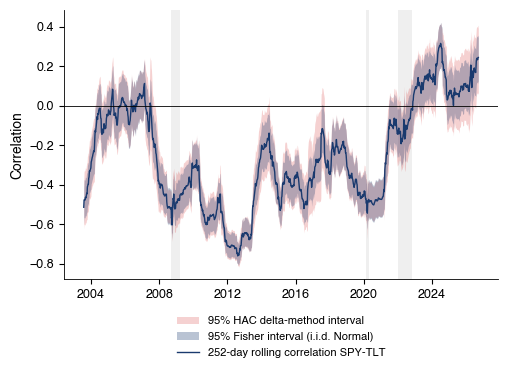

   saved ch6_corr_hac


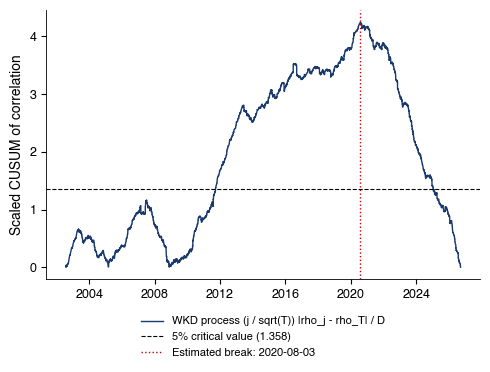

   saved ch6_wkd


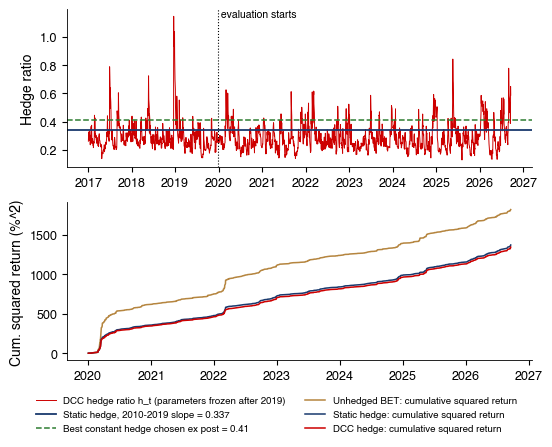

   saved ch6_hedge_oos


{'hac_ratio_med': 1.242572989275828,
 'hac_ratio_q90': np.float64(1.5394076987391305),
 'hac_ratio_max': 2.0202761551269313,
 'hac_share_flip': np.float64(0.0815450643776824),
 'hac_share_sig_f': np.float64(0.7270386266094421),
 'hac_share_sig_h': np.float64(0.6454935622317597),
 'hac_nwin': 1165,
 'hac_last_rho': np.float64(0.24500667655169753),
 'hac_last_lo_f': np.float64(0.125225167256577),
 'hac_last_hi_f': np.float64(0.35774827602002746),
 'hac_last_lo_h': np.float64(0.06684754483375252),
 'hac_last_hi_h': np.float64(0.40802536451116544),
 'hac_last_date': '2026-09-17',
 'hac_pre_rho': np.float64(-0.40333690264814603),
 'hac_pre_se_fisher': np.float64(0.011976378842699002),
 'hac_pre_se_iid': np.float64(0.021689974311116317),
 'hac_pre_se_hac': np.float64(0.022651629671545704),
 'hac_pre_T': 4891,
 'hac_pre_L': 9,
 'hac_post_rho': np.float64(0.1100894205059668),
 'hac_post_se_fisher': np.float64(0.02877050142121132),
 'hac_post_se_iid': np.float64(0.03673279284458646),
 'hac_post

In [7]:
fig_corr_hac()
fig_wkd()
hedge_oos()
fr_bootstrap(CALM08, CRISIS08, '08')
two_step_bootstrap(B=49)   # 199 in the lecture; fewer here for speed
ccc_null_bootstrap(['spy', 'tlt'], 'cccb', B=49)   # 199 in the lecture
{k: v for k, v in N.items() if k.startswith(('hac', 'wkd', 'ts_', 'ho_', 'frb_08', 'cccb'))}

![ch6_corr_hac](./ch6_corr_hac.png)

Output: `ch6_corr_hac.pdf`

![ch6_wkd](./ch6_wkd.png)

Output: `ch6_wkd.pdf`

![ch6_hedge_oos](./ch6_hedge_oos.png)

Output: `ch6_hedge_oos.pdf`